# Álgebra Lineal con NumPy

En los notebooks anteriores aprendimos a crear y manipular `ndarray`s: indexing, reshaping, broadcasting, operaciones vectorizadas. Ahora vamos a usar todo eso para hacer **álgebra lineal**, que es básicamente el lenguaje matemático en el que está escrito el machine learning, la visión computacional, la física computacional y muchas cosas más.

La buena noticia es que NumPy tiene un submódulo dedicado a esto: `numpy.linalg`. La mala noticia es que primero hay que entender qué significa cada operación antes de llamarla.

Los temas que cubriremos:

1. Vectores y matrices en NumPy
2. Transpuesta
3. Producto punto (dot product)
4. Multiplicación de matrices
5. Normas
6. Matriz identidad e inversa
7. Determinante y rango
8. Sistemas de ecuaciones lineales
9. Eigenvalores y eigenvectores
10. Descomposición en valores singulares (SVD)

In [ ]:
import numpy as np
print(f"NumPy version: {np.__version__}")

---
# 1. Vectores y Matrices en NumPy

En álgebra lineal los objetos fundamentales son los **vectores** (arreglos 1D) y las **matrices** (arreglos 2D). NumPy los representa directamente con `ndarray`, así que ya sabes usarlos.

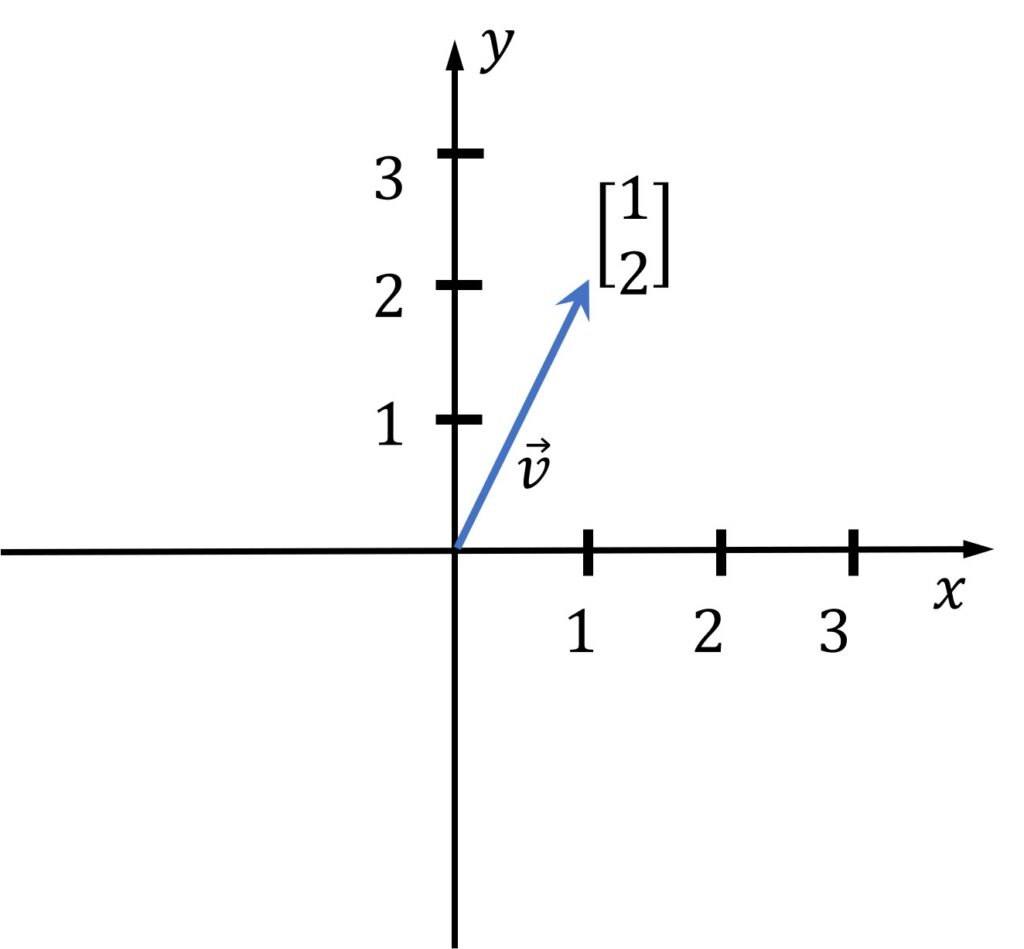



La única convención importante: un vector en álgebra lineal puede ser **columna** (shape `(n, 1)`) o **fila** (shape `(1, n)`), y eso importa en muchas operaciones. NumPy por default crea vectores de shape `(n,)`, que es ni lo uno ni lo otro — es un arreglo 1D plano. Tenlo en mente.

In [ ]:
# Vector 1D — shape (3,)
v = np.array([1, 2, 3])
print("Vector:", v)
print("Shape: ", v.shape)

In [ ]:
# Vector columna — shape (3, 1)
v_col = v.reshape(-1, 1)
print("Vector columna:\n", v_col)
print("Shape:", v_col.shape)

print()

# Vector fila — shape (1, 3)
v_row = v.reshape(1, -1)
print("Vector fila:\n", v_row)
print("Shape:", v_row.shape)

In [ ]:
# Matriz — arreglo 2D de shape (filas, columnas)
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print("Matriz A:\n", A)
print("Shape:", A.shape)   # (3, 3)
print("Dimensiones:", A.ndim)

In [ ]:
# Matrices de utilidad que ya vienen en NumPy

# Matriz de ceros
print(np.zeros((3, 3)))
print()

# Matriz de unos
print(np.ones((2, 4)))
print()

# Matriz diagonal — pones los valores de la diagonal
print(np.diag([1, 2, 3]))

---
# 2. Transpuesta

La transpuesta de una matriz **intercambia filas por columnas**. Una matriz de shape `(m, n)` transpuesta tiene shape `(n, m)`. Se denota $A^T$.

En NumPy accedes a la transpuesta con el atributo `.T` — no es una función, es un atributo (y es una vista, no una copia).

In [ ]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])   # shape (2, 3)

print("A:\n", A)
print("Shape A:", A.shape)
print()
print("A.T:\n", A.T)
print("Shape A.T:", A.T.shape)   # → (3, 2)

In [ ]:
# La transpuesta de un vector 1D no hace nada visible
v = np.array([1, 2, 3])   # shape (3,)
print("v:  ", v,   "shape:", v.shape)
print("v.T:", v.T, "shape:", v.T.shape)   # shape sigue siendo (3,) !

# Para transponer un vector 1D de verdad, primero dale shape 2D
v_col = v.reshape(-1, 1)           # shape (3, 1)
print("v_col.T shape:", v_col.T.shape)  # → (1, 3)

### ⚠️ Transponer un arreglo 1D no hace nada

Es uno de los errores más comunes viniendo de MATLAB o de leer ecuaciones en papel. Si tienes un vector `(n,)` y le aplicas `.T`, NumPy lo ignora silenciosamente porque un arreglo 1D no tiene "orientación". Siempre que necesites que un vector tenga orientación explícita (columna o fila), dale shape 2D primero.

---
# 3. Producto Punto (Dot Product)

El producto punto entre dos vectores $\mathbf{a}$ y $\mathbf{b}$ de tamaño $n$ es:

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_i b_i = a_1 b_1 + a_2 b_2 + \cdots + a_n b_n$$

El resultado es un **escalar**. Geométricamente, mide qué tanto apuntan en la misma dirección dos vectores: si es 0, son perpendiculares (ortogonales); si es positivo, apuntan "en el mismo sentido".

In [ ]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Tres formas de calcular el producto punto — todas equivalentes
print(np.dot(a, b))     # función explícita
print(a @ b)            # operador @ (Python 3.5+, más limpio)
print(np.sum(a * b))    # a mano: multiplicar elemento a elemento y sumar

In [ ]:
# El producto punto es conmutativo: a·b == b·a
print(a @ b == b @ a)   # True

In [ ]:
# Dos vectores ortogonales tienen producto punto = 0
e1 = np.array([1, 0, 0])   # vector unitario eje X
e2 = np.array([0, 1, 0])   # vector unitario eje Y

print("e1 · e2 =", e1 @ e2)   # → 0, son perpendiculares
print("e1 · e1 =", e1 @ e1)   # → 1, producto con sí mismo

---
# 4. Multiplicación de Matrices

La multiplicación de matrices es **la** operación central del álgebra lineal. Para multiplicar $A \times B$, el número de **columnas de A** debe ser igual al número de **filas de B**.

$$A_{(m \times k)} \cdot B_{(k \times n)} = C_{(m \times n)}$$

Cada elemento $C_{ij}$ es el producto punto de la fila $i$ de $A$ con la columna $j$ de $B$.

> Nota importante: La multiplicación de matrices **no** es conmutativa. $A \cdot B \neq B \cdot A$ en general.

In [ ]:
A = np.array([
    [1, 2],
    [3, 4]
])   # shape (2, 2)

B = np.array([
    [5, 6],
    [7, 8]
])   # shape (2, 2)

# El operador @ hace multiplicación matricial
C = A @ B
print("A @ B:\n", C)

print()

# np.matmul es exactamente lo mismo que @
print("np.matmul(A, B):\n", np.matmul(A, B))

In [ ]:
# La multiplicación NO es conmutativa
print("A @ B:\n", A @ B)
print()
print("B @ A:\n", B @ A)

In [ ]:
# Ejemplo con shapes distintos
# A es (3, 4), B es (4, 2) → resultado es (3, 2)
A = np.random.randint(1, 5, size=(3, 4))
B = np.random.randint(1, 5, size=(4, 2))

C = A @ B
print(f"A.shape={A.shape}  B.shape={B.shape}  →  C.shape={C.shape}")
print(C)

### ⚠️ `@` vs `*` — no son lo mismo

- `A * B` → multiplicación **elemento a elemento** (requiere misma shape, como siempre en NumPy)
- `A @ B` → multiplicación **matricial** (producto punto de filas por columnas)

Es un error muy fácil de cometer, especialmente si vienes de MATLAB donde `.*` es elemento a elemento y `*` es matricial.

In [ ]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[2, 0], [1, 3]])

print("A * B (elemento a elemento):\n", A * B)
print()
print("A @ B (matricial):\n", A @ B)

---
# 5. Normas

La **norma** de un vector es su "tamaño" o longitud. La más común es la norma Euclidiana (norma-2):

$$\|\mathbf{v}\|_2 = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}$$

Pero hay otras normas útiles. `np.linalg.norm` las calcula todas.

In [ ]:
v = np.array([3.0, 4.0])

# Norma-2 (Euclidiana) — la default
print("Norma-2:  ", np.linalg.norm(v))       # → 5.0 (triángulo 3-4-5)

# Norma-1 (Manhattan) — suma de valores absolutos
print("Norma-1:  ", np.linalg.norm(v, ord=1)) # → 7.0

# Norma-inf — máximo valor absoluto
print("Norma-inf:", np.linalg.norm(v, ord=np.inf))  # → 4.0

# A mano para verificar
print("A mano:   ", np.sqrt(np.sum(v**2)))    # → 5.0

In [ ]:
# Normalizar un vector — hacerlo unitario (norma = 1)
# Se usa mucho en ML para comparar direcciones sin importar magnitud
v = np.array([3.0, 4.0])
v_unitario = v / np.linalg.norm(v)

print("Vector original:  ", v,          "norma:", np.linalg.norm(v))
print("Vector unitario:  ", v_unitario, "norma:", np.linalg.norm(v_unitario))

In [ ]:
# Las normas también aplican a matrices
A = np.array([[1, 2], [3, 4]], dtype=float)

# Norma de Frobenius — raíz cuadrada de la suma de todos los elementos al cuadrado
# Es el equivalente matricial de la norma-2 de un vector
print("Norma Frobenius:", np.linalg.norm(A, ord='fro'))
print("A mano:         ", np.sqrt(np.sum(A**2)))

---
# 6. Matriz Identidad e Inversa

## 6.1 Matriz Identidad

La matriz identidad $I$ es la matriz cuadrada con 1s en la diagonal y 0s en el resto. Es el equivalente del número 1 para la multiplicación: $A \cdot I = I \cdot A = A$.

In [ ]:
# np.eye(n) crea la identidad de tamaño n×n
I = np.eye(3)
print("Identidad 3x3:\n", I)

In [ ]:
A = np.array([[2, 1], [5, 3]], dtype=float)
I = np.eye(2)

# Multiplicar por identidad no cambia la matriz
print("A @ I:\n", A @ I)
print()
print("I @ A:\n", I @ A)

## 6.2 Inversa de una Matriz

La inversa de una matriz $A$ es aquella matriz $A^{-1}$ tal que:

$$A \cdot A^{-1} = A^{-1} \cdot A = I$$

Solo existe si la matriz es **cuadrada** y su determinante es distinto de 0 (es decir, si es invertible). `np.linalg.inv` la calcula.

In [ ]:
A = np.array([[2, 1], [5, 3]], dtype=float)
A_inv = np.linalg.inv(A)

print("A:\n", A)
print()
print("A_inv:\n", A_inv)

In [ ]:
# Verificamos: A @ A_inv debe dar la identidad
resultado = A @ A_inv
print("A @ A_inv:\n", resultado)

# Hay un poco de error numérico flotante, redondeamos para verificar
print("\nRedondeado:\n", np.round(resultado))

### ⚠️ La inversa es cara — úsala solo si la necesitas en sí misma

Calcular la inversa de una matriz es computacionalmente costoso ($O(n^3)$). Si tu objetivo es resolver un sistema $Ax = b$, **no hagas** `np.linalg.inv(A) @ b`. Usa directamente `np.linalg.solve(A, b)` — es más rápido y más numéricamente estable. Lo veremos en la sección 8.

---
# 7. Determinante y Rango

## 7.1 Determinante

El determinante es un número escalar asociado a una matriz cuadrada. Intuitivamente, representa el **factor por el que la transformación lineal escala el volumen** del espacio.

- $\det(A) \neq 0$ → la matriz es invertible (no singular)
- $\det(A) = 0$ → la matriz es singular, no tiene inversa, y el sistema $Ax = b$ puede no tener solución única

In [ ]:
A = np.array([[2, 1], [5, 3]], dtype=float)
print("det(A):", np.linalg.det(A))   # → 1.0  (2*3 - 1*5)

In [ ]:
# Matriz singular — filas linealmente dependientes
# (la fila 2 es el doble de la fila 1)
B = np.array([
    [1, 2],
    [2, 4]
], dtype=float)

print("det(B):", np.linalg.det(B))   # → 0  (o muy cercano por errores flotantes)

In [ ]:
# Qué pasa si intentas invertir una matriz singular
try:
    B_inv = np.linalg.inv(B)
    print(B_inv)   # NumPy no siempre lanza error — puede darte inf o nan
except np.linalg.LinAlgError as e:
    print(f"Error: {e}")

## 7.2 Rango (Rank)

El rango de una matriz es el número de **filas (o columnas) linealmente independientes**. Básicamente mide cuánta información "real" contiene la matriz — cuántas dimensiones del espacio realmente transforma.

- Para una matriz $m \times n$, el rango máximo posible es $\min(m, n)$
- Si el rango es menor que ese máximo, la matriz es **rank-deficient** (tiene redundancia)

In [ ]:
# Matriz de rango completo
A = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])
print("Rango de I:", np.linalg.matrix_rank(A))   # → 3

# Matriz con fila dependiente (fila3 = fila1 + fila2)
B = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [5, 7, 9]   # = fila0 + fila1
])
print("Rango de B:", np.linalg.matrix_rank(B))   # → 2, no 3

---
# 8. Sistemas de Ecuaciones Lineales

Un sistema de ecuaciones lineales se puede escribir en forma matricial como:

$$A \mathbf{x} = \mathbf{b}$$

Donde $A$ es la matriz de coeficientes, $\mathbf{x}$ es el vector de incógnitas y $\mathbf{b}$ es el vector de resultados.

Por ejemplo, el sistema:
$$2x + y = 5$$
$$5x + 3y = 13$$

Se convierte en:
$$\begin{pmatrix} 2 & 1 \\ 5 & 3 \end{pmatrix} \begin{pmatrix} x \\ y \end{pmatrix} = \begin{pmatrix} 5 \\ 13 \end{pmatrix}$$

In [ ]:
# Definimos el sistema
A = np.array([[2, 1],
              [5, 3]], dtype=float)

b = np.array([5, 13], dtype=float)

# Resolvemos con np.linalg.solve
x = np.linalg.solve(A, b)
print("Solución x:", x)   # → x=2, y=1

In [ ]:
# Verificamos: A @ x debe reproducir b
print("A @ x:", A @ x)   # → [5. 13.]
print("b:    ", b)
print("¿Iguales?", np.allclose(A @ x, b))   # np.allclose tolera pequeños errores flotantes

In [ ]:
# Sistema 3x3 — más ecuaciones, más incógnitas
# x + 2y + z = 9
# 2x + y + z = 8
# x + y + 2z = 9

A3 = np.array([
    [1, 2, 1],
    [2, 1, 1],
    [1, 1, 2]
], dtype=float)

b3 = np.array([9, 8, 9], dtype=float)

x3 = np.linalg.solve(A3, b3)
print("Solución:", x3)
print("Verificación:", np.allclose(A3 @ x3, b3))

> **`np.linalg.solve` vs `inv`:** Internamente, `solve` usa factorización LU en lugar de calcular la inversa explícitamente. Es más rápido y más estable numéricamente. Si solo necesitas resolver $Ax = b$, siempre prefiere `solve`.

---
# 9. Eigenvalores y Eigenvectores

Dado que la multiplicación por una matriz $A$ es una transformación lineal (rota, escala, sesga el espacio), los **eigenvectores** son vectores especiales que **no cambian de dirección** al aplicarles esa transformación — solo se escalan.

Matemáticamente, $\mathbf{v}$ es eigenvector de $A$ con eigenvalor $\lambda$ si:

$$A \mathbf{v} = \lambda \mathbf{v}$$

Los eigenvalores y eigenvectores son fundamentales en PCA, compresión de datos, estabilidad de sistemas, y muchos algoritmos de ML.

In [ ]:
A = np.array([[3, 1],
              [0, 2]], dtype=float)

# np.linalg.eig regresa dos cosas:
# eigenvalues  → arreglo 1D con los eigenvalores
# eigenvectors → matriz donde CADA COLUMNA es un eigenvector
eigenvalores, eigenvectores = np.linalg.eig(A)

print("Eigenvalores: ", eigenvalores)
print("Eigenvectores:\n", eigenvectores)

In [ ]:
# Verificamos la definición: A @ v debe ser igual a λ * v
for i in range(len(eigenvalores)):
    lam = eigenvalores[i]
    v   = eigenvectores[:, i]   # columna i = eigenvector i

    Av    = A @ v
    lam_v = lam * v

    print(f"λ={lam:.1f}  →  A@v={np.round(Av, 4)}  |  λ*v={np.round(lam_v, 4)}  |  ✓ {np.allclose(Av, lam_v)}")

In [ ]:
# Para matrices simétricas usa np.linalg.eigh — es más rápido
# y garantiza eigenvalores reales (eig puede dar complejos en casos raros)
A_sim = np.array([[4, 2],
                  [2, 3]], dtype=float)

vals, vecs = np.linalg.eigh(A_sim)
print("Eigenvalores (eigh):", vals)
print("Eigenvectores:\n", vecs)

---
# 10. Descomposición en Valores Singulares (SVD)

SVD es la generalización de la descomposición en eigenvalores para matrices **no cuadradas**. Cualquier matriz $A$ de shape $(m \times n)$ se puede factorizar como:

$$A = U \Sigma V^T$$

- $U$ → matriz $(m \times m)$ — las "direcciones" en el espacio de filas
- $\Sigma$ → vector de **valores singulares** (siempre positivos, ordenados de mayor a menor)
- $V^T$ → matriz $(n \times n)$ — las "direcciones" en el espacio de columnas

SVD aparece en PCA, compresión de imágenes, sistemas de recomendación, pseudoinversa, y más.

In [ ]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
], dtype=float)   # shape (2, 3)

U, S, Vt = np.linalg.svd(A)

print("U  shape:", U.shape)    # (2, 2)
print("S  shape:", S.shape)    # (2,)  — solo los valores singulares, no la matriz diagonal completa
print("Vt shape:", Vt.shape)   # (3, 3)
print()
print("Valores singulares:", S)

In [ ]:
# Reconstruir A desde sus componentes SVD
# S es un vector 1D, necesitamos convertirlo a matriz diagonal para hacer la multiplicación
Sigma = np.zeros_like(A)   # matriz de ceros con shape (2, 3)
Sigma[:len(S), :len(S)] = np.diag(S)

A_reconstruida = U @ Sigma @ Vt
print("A original:\n", A)
print()
print("A reconstruida (U @ Σ @ Vt):\n", np.round(A_reconstruida, 10))
print()
print("¿Igual?", np.allclose(A, A_reconstruida))

In [ ]:
# Aplicación clásica: aproximación de rango bajo
# Si te quedas solo con los k valores singulares más grandes,
# obtienes la "mejor" aproximación de rango k de la matriz original

# Con k=1 (solo el valor singular más grande)
k = 1
A_aprox = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

print("A original:\n", A)
print()
print(f"Aproximación rango {k}:\n", np.round(A_aprox, 2))
print()
# Error de la aproximación
print("Error (norma Frobenius):", np.round(np.linalg.norm(A - A_aprox), 4))

> Esta idea de aproximación de rango bajo es exactamente lo que hace **PCA** internamente: encontrar las direcciones de mayor varianza usando SVD y descartar las de menor varianza para comprimir los datos.

---
# Resumen

| Tema | Función / operación | Para qué sirve |
|------|--------------------|-----------------|
| **Transpuesta** | `A.T` | Intercambiar filas y columnas |
| **Producto punto** | `a @ b`, `np.dot(a, b)` | Similitud entre vectores, proyecciones |
| **Multiplicación matricial** | `A @ B`, `np.matmul(A, B)` | Transformaciones lineales compuestas |
| **Norma** | `np.linalg.norm(v)` | Magnitud de un vector o matriz |
| **Identidad** | `np.eye(n)` | Elemento neutro de la multiplicación |
| **Inversa** | `np.linalg.inv(A)` | Deshacer una transformación lineal |
| **Determinante** | `np.linalg.det(A)` | Verificar si una matriz es invertible |
| **Rango** | `np.linalg.matrix_rank(A)` | Independencia lineal de filas/columnas |
| **Sistemas lineales** | `np.linalg.solve(A, b)` | Resolver $Ax = b$ eficientemente |
| **Eigendescomposición** | `np.linalg.eig(A)` | Direcciones invariantes de una transformación |
| **SVD** | `np.linalg.svd(A)` | Factorización general, base de PCA |

En el siguiente notebook vamos a aplicar todo esto en un contexto de datos reales: usaremos SVD para comprimir imágenes y PCA desde cero para reducir dimensionalidad.